# Modules

Does PANCAST assign elevated probability near locations where a convective core will initiate within the next 0–3 hours?

In [147]:
import sys
sys.path.insert(1, "../module")
import snflics

import numpy as np      

from netCDF4 import Dataset                             

import cartopy.crs as ccrs                              
import cartopy.feature as cfeature                   
import matplotlib.pyplot as plt            

plt.style.use('default')                               
plt.rcParams['figure.facecolor'] = 'white'

import warnings
warnings.filterwarnings("ignore")
import cartopy.io.shapereader as shpreader

import pandas as pd
from pathlib import Path

In [148]:
# load
geodata = np.load("/gws/nopw/j04/cocoon/SSA_domain/lat_lon_2268_2080.npz")

lons = geodata["lon"][:, :]
lats = geodata["lat"][:, :]

y_min, y_max = 48, 2062
x_min, x_max = 81, 2267

lats = lats[y_min:y_max+1, x_min:x_max+1]
lons = lons[y_min:y_max+1, x_min:x_max+1]

# $t_0$

In [149]:
year = "2023"
month = "08"
day = "01"
hour = "12"
minute = "00"

In [150]:
path_core_t0 = f'/gws/nopw/j04/cocoon/SSA_domain/ch9_wavelet/{year}/{month}'
file = f'{path_core_t0}/{year}{month}{day}{hour}{minute}.nc'

data = Dataset(file, mode='r')
temp_t0  = data["tir"][0, y_min:y_max+1, x_min:x_max+1]
cores_t0 = data["cores"][0, y_min:y_max+1, x_min:x_max+1]
binary_cores = (cores_t0 != 0).astype(int)

# Initiation at $t_0$

In [151]:
BASE_PATH = Path("/gws/nopw/j04/wiser_ewsa/mrakotomanga/initiations/txt_op")

COLUMNS = [
    "mo", "dy", "hr", "mn",
    "lat", "lon",
    "i_c", "j_c", "i", "j",
    "topo_sd", "wf", "minT", "Rmax"
]

def load_month_file(filepath):
    year = int(filepath.name[5:9])
    month = int(filepath.name[9:11])

    df = pd.read_csv(
        filepath,
        delim_whitespace=True,
        skiprows=1,
        names=COLUMNS
    )

    df["year"] = year

    df["datetime"] = pd.to_datetime(
        dict(
            year=df["year"],
            month=df["mo"],
            day=df["dy"],
            hour=df["hr"],
            minute=df["mn"]
        ),
        utc=True
    )

    return df


def get_initiations_at_time(timestamp):
    timestamp = pd.to_datetime(timestamp, utc=True)

    filepath = BASE_PATH / f"init_{timestamp:%Y%m}_T40_vn3_30km.txt"

    if not filepath.exists():
        raise FileNotFoundError(f"Missing file: {filepath}")

    df = load_month_file(filepath)

    return df[df["datetime"] == timestamp]


In [152]:

timestamp = f"{year}-{month}-{day} {hour}:{minute}"

init = get_initiations_at_time(timestamp)

print(len(init))
print(init[["lat", "lon", "minT", "Rmax"]])


10
      lat    lon  minT  Rmax
76   0.61  30.94   -70   5.0
77   0.84  31.56   -68   3.4
78   0.89  26.70   -75   4.6
79   1.06  30.06   -75   3.2
80   2.00  27.78   -69   0.5
81   3.49  30.87   -68   4.6
82   6.71  11.54   -74  13.6
83  11.86   8.74   -50   0.6
84  15.75  27.03   -64   0.3
85  18.06  33.90   -78   4.6


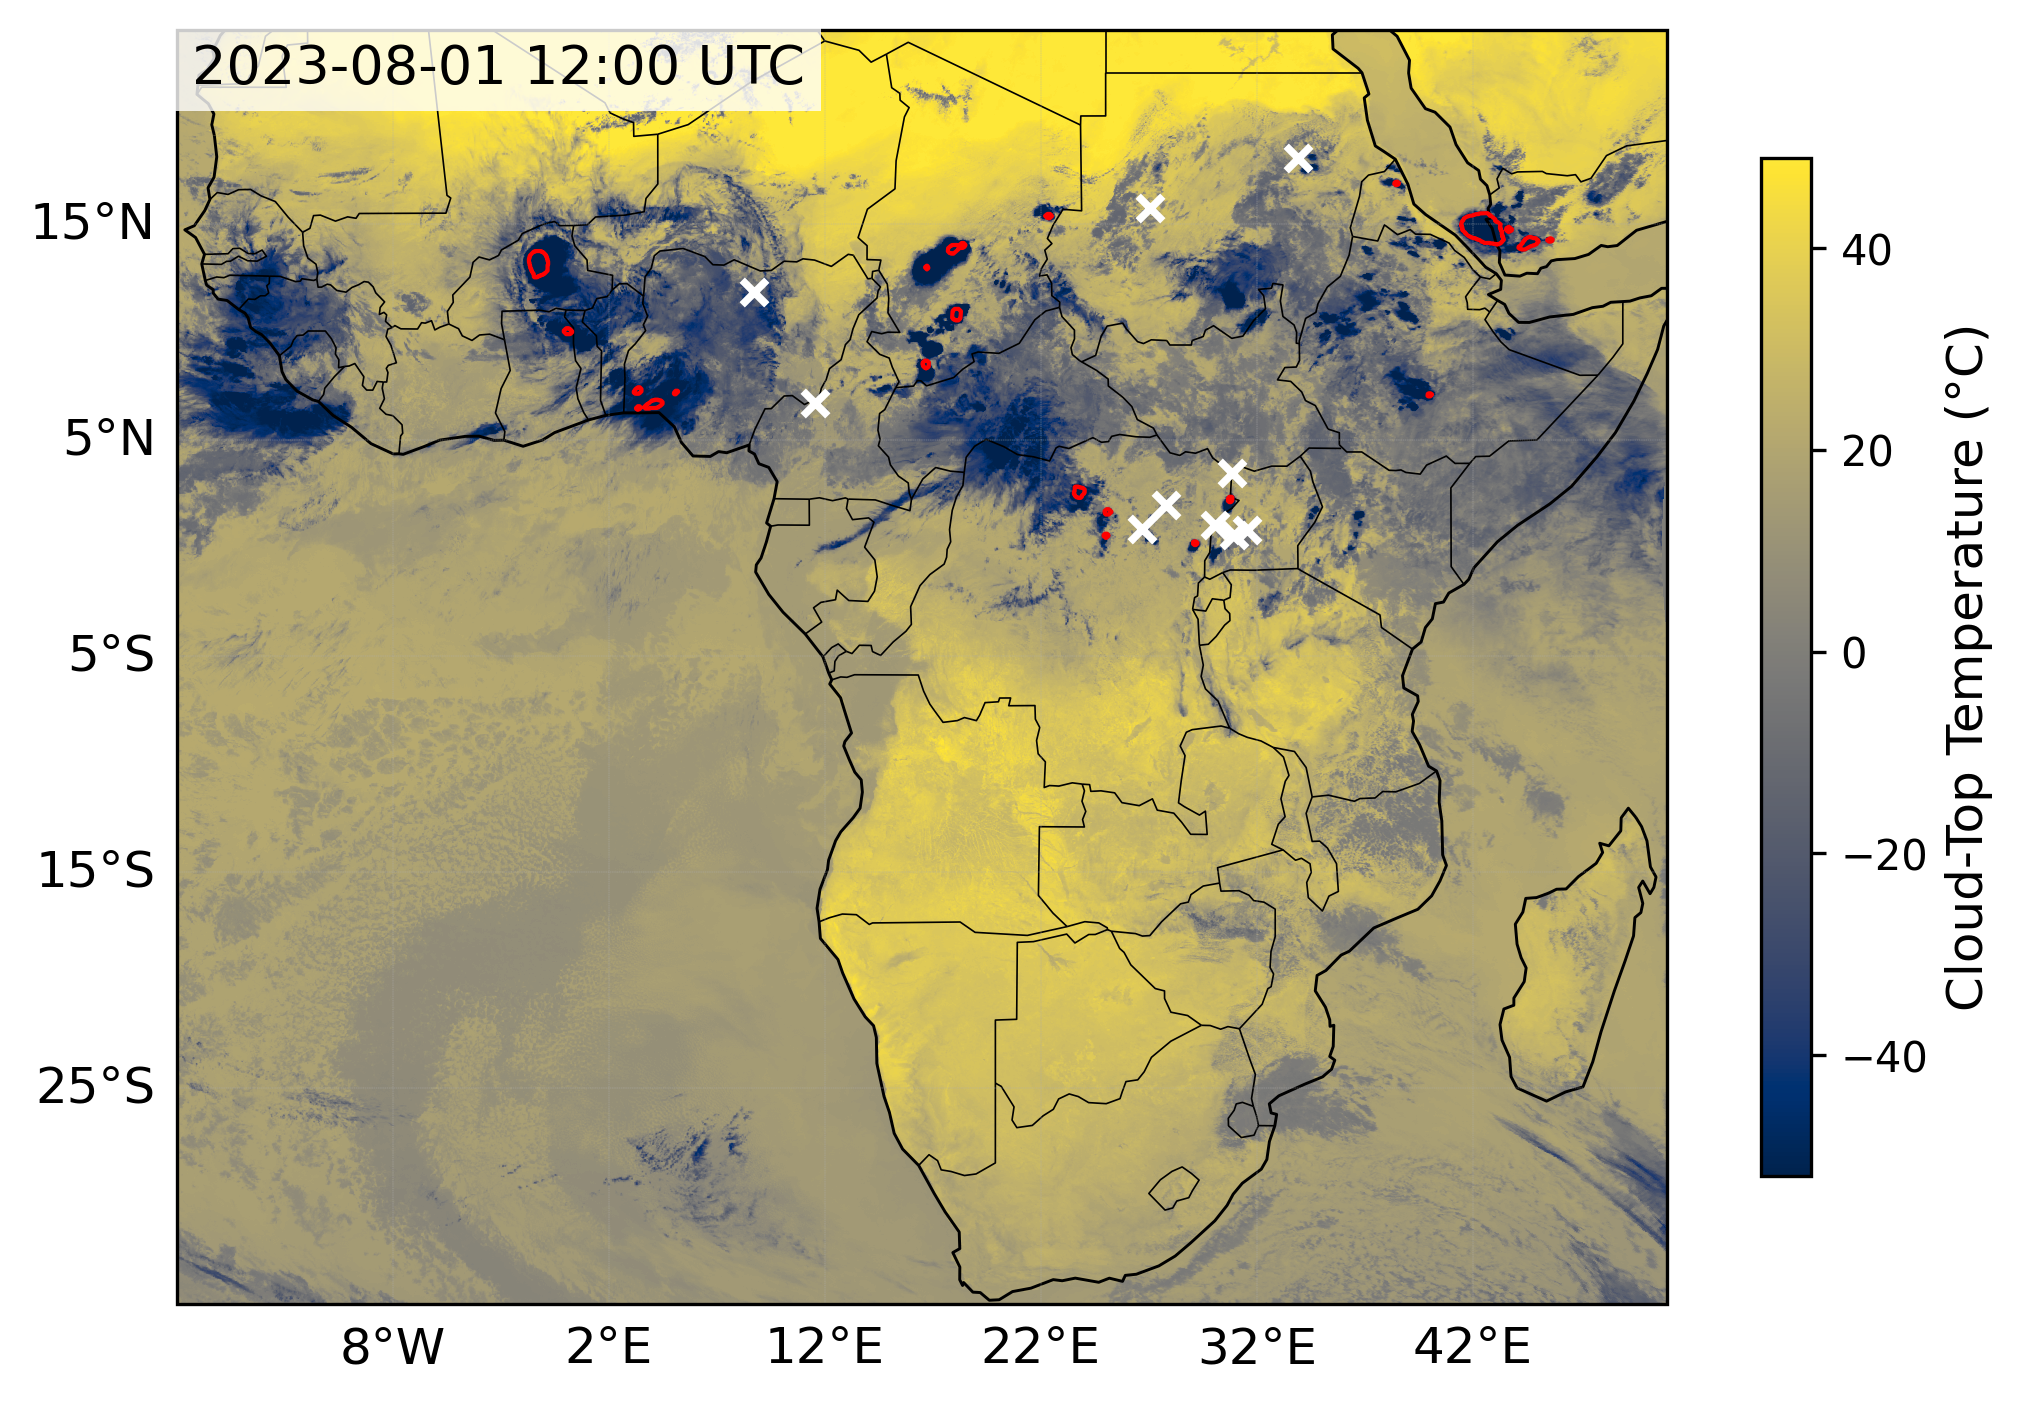

In [153]:
fig = plt.figure(figsize=(7, 10), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

extent = (-18, 51, -35, 24)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# base map
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.6)
ax.add_feature(cfeature.OCEAN, facecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

# gridlines
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10),
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# CTT background
p = ax.pcolormesh(
    lons,
    lats,
    temp_t0,
    cmap="cividis",
    vmin=np.nanpercentile(temp_t0, 1),
    vmax=np.nanpercentile(temp_t0, 97),
    shading="auto",
    zorder=1,
)

ax.text(
    0.01,
    0.99,
    f"{timestamp} UTC",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    zorder=5,
)


# core outlines
ax.contour(
    lons,
    lats,
    cores_t0,
    levels=[0.5],
    colors="red",
    linewidths=1.0,
    zorder=3,
)

# initiation locations
ax.scatter(
    init["lon"],
    init["lat"],
    s=35,
    marker="x",
    linewidths=1.8,
    color="white",
    transform=ccrs.PlateCarree(),
    zorder=4,
)

cb = plt.colorbar(p, ax=ax, shrink=0.35)
cb.set_label("Cloud-Top Temperature (°C)", fontsize=12)

plt.tight_layout()
plt.show()

# Loading nowcast at ground truth at a given valid time

In [154]:
from pathlib import Path
import torch

def load_nowcast_and_gt(year, month, day, hour, minute, lead_time):

    year   = int(year)
    month  = int(month)
    day    = int(day)
    hour   = int(hour)
    minute = int(minute)
    lead_time = int(lead_time)

    NOWCAST_ROOT = f"/gws/ssde/j25b/swift/mendrika/pancast/nowcasts/t{lead_time:03d}min"

    fpath = (
        f"{NOWCAST_ROOT}/"
        f"{year}{month:02d}/"
        f"{hour:02d}/"
        f"pred_{year}{month:02d}{day:02d}_{hour:02d}{minute:02d}.pt"
    )

    if not Path(fpath).exists():
        raise FileNotFoundError(fpath)

    data = torch.load(fpath, map_location="cpu")

    nowcast = data["mean"].numpy()
    gt = data["gt"].numpy()

    return nowcast, gt

In [155]:
print(year, month, day, hour, minute)

2023 08 01 12 00


In [156]:
lead_time = 30

nowcast, gt = load_nowcast_and_gt(year, month, day, hour, minute, lead_time)

In [157]:
nowcast_masked = np.ma.masked_where(nowcast == 0, nowcast)

In [158]:
import cartopy.geodesic as cgeo

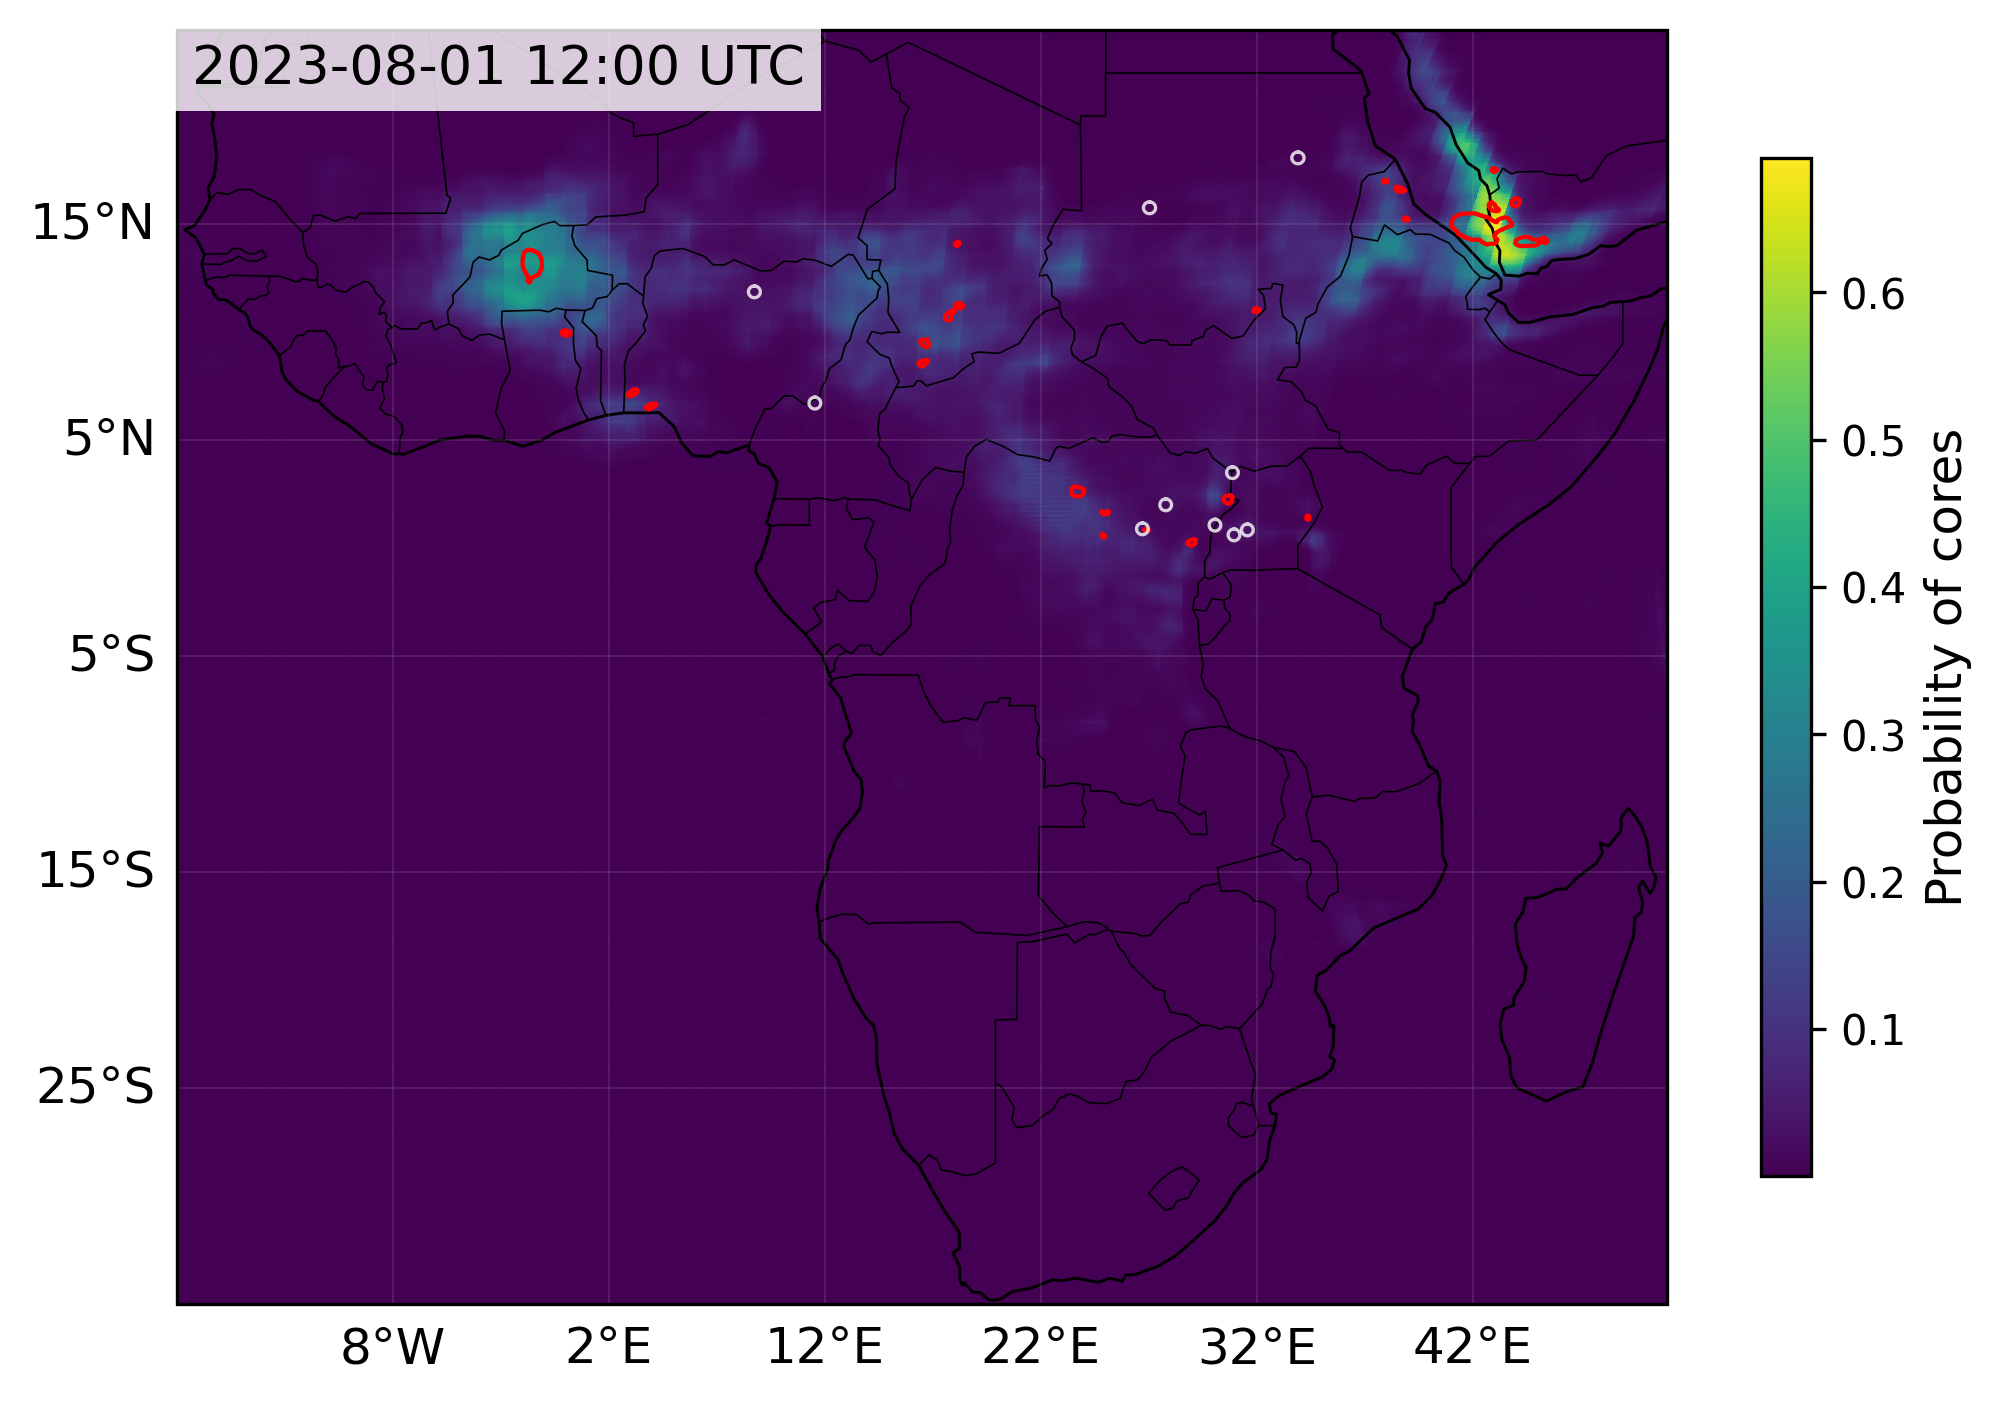

In [159]:
fig = plt.figure(figsize=(7, 10), dpi=300)
ax = plt.axes(projection=ccrs.PlateCarree())

extent = (-18, 51, -35, 24)
ax.set_extent(extent, crs=ccrs.PlateCarree())

# base map
ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.6)
ax.add_feature(cfeature.OCEAN, facecolor="none")
ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
ax.add_feature(cfeature.BORDERS, linewidth=0.4)

# gridlines
gl = ax.gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10),
)

gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {"size": 12}
gl.ylabel_style = {"size": 12}

# CTT background
p = ax.pcolormesh(
    lons,
    lats,
    nowcast_masked,
    cmap="viridis",
    shading="auto",
    zorder=1,
)

ax.text(
    0.01,
    0.99,
    f"{timestamp} UTC",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=13,
    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8),
    zorder=5,
)


# core outlines
ax.contour(
    lons,
    lats,
    gt,
    levels=[0.5],
    colors="red",
    linewidths=1.0,
    zorder=3,
)

# draw 30 km radius circles around initiation points
geod = cgeo.Geodesic()

radius_m = 30_000  # 30 km in metres

for lon0, lat0 in zip(init["lon"], init["lat"]):
    circle = geod.circle(
        lon=lon0,
        lat=lat0,
        radius=radius_m,
        n_samples=100,
    )
    ax.plot(
        circle[:, 0],
        circle[:, 1],
        color="white",
        linewidth=0.8,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=8,
    )


cb = plt.colorbar(p, ax=ax, shrink=0.35)
cb.set_label("Probability of cores", fontsize=12)

plt.tight_layout()
plt.show()

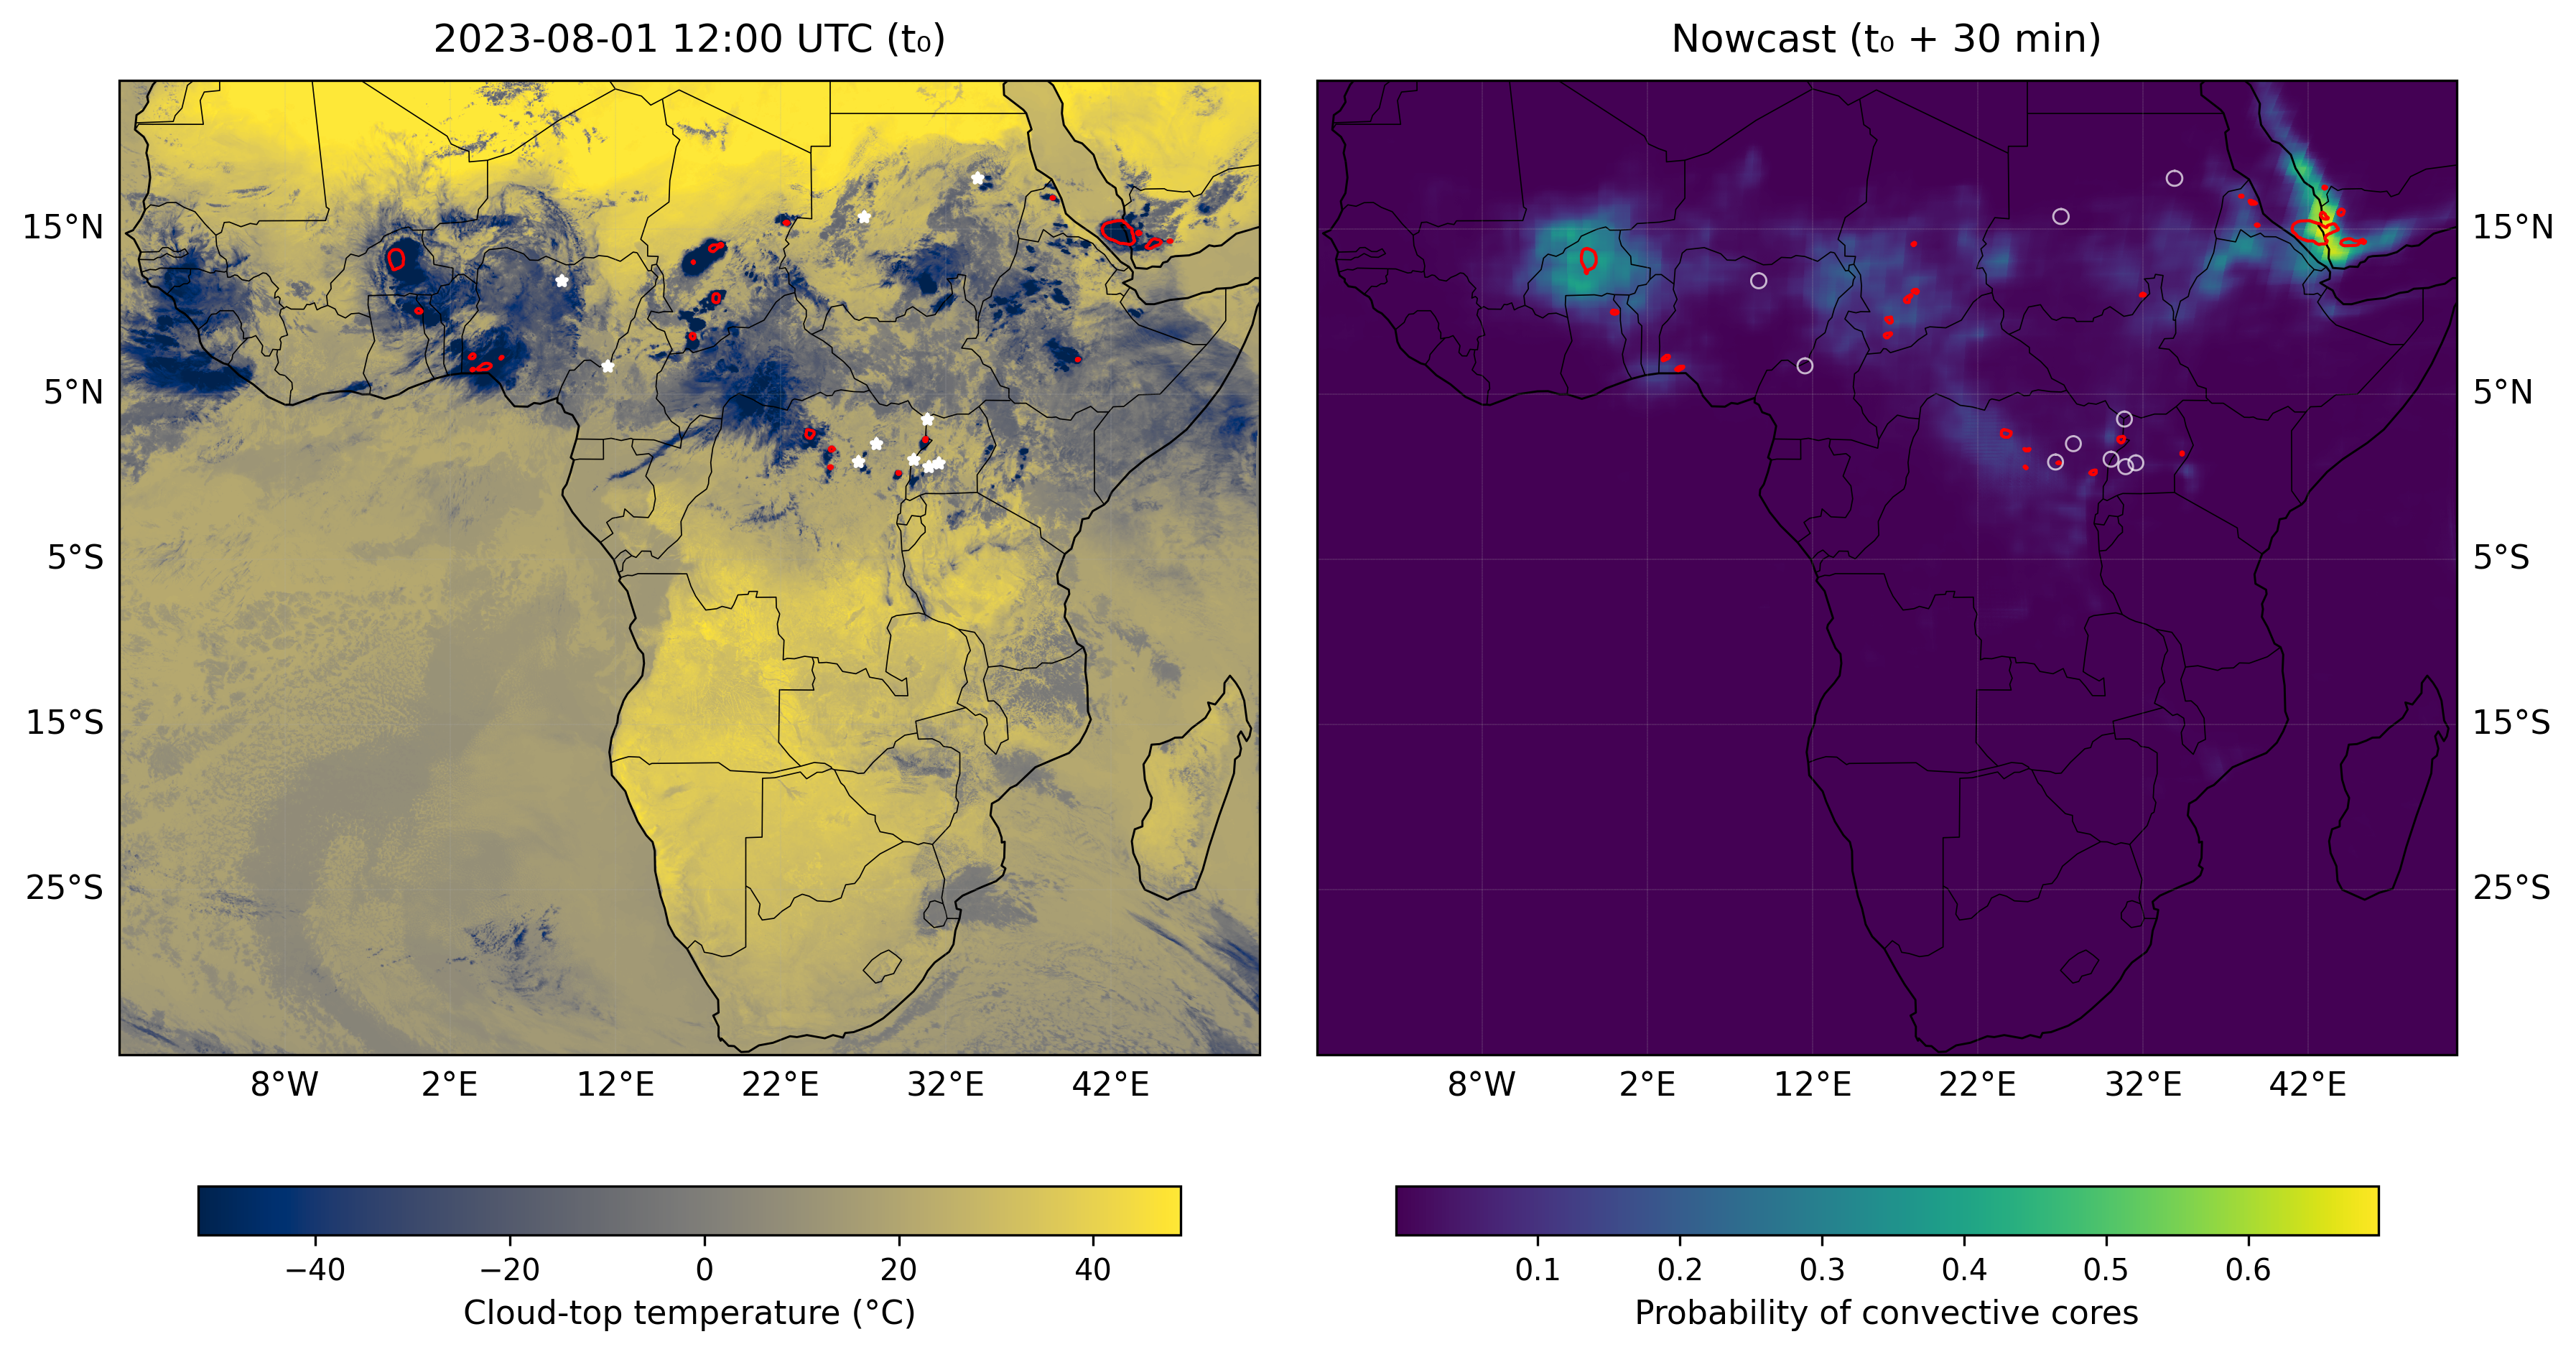

In [160]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 10),
    dpi=300,
    subplot_kw={"projection": ccrs.PlateCarree()},
)

extent = (-18, 51, -35, 24)

for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.6)
    ax.add_feature(cfeature.OCEAN, facecolor="none")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7)
    ax.add_feature(cfeature.BORDERS, linewidth=0.4)

# Gridlines: left panel shows left y labels, right panel shows right y labels
gl0 = axes[0].gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10),
)
gl0.top_labels = False
gl0.right_labels = False
gl0.left_labels = True
gl0.bottom_labels = True
gl0.xlabel_style = {"size": 11}
gl0.ylabel_style = {"size": 11}

gl1 = axes[1].gridlines(
    draw_labels=True,
    linestyle="--",
    linewidth=0.1,
    xlocs=np.arange(round(extent[0]), round(extent[1]), 10),
    ylocs=np.arange(round(extent[-2]), round(extent[-1]), 10),
)
gl1.top_labels = False
gl1.left_labels = False
gl1.right_labels = True
gl1.bottom_labels = True
gl1.xlabel_style = {"size": 11}
gl1.ylabel_style = {"size": 11}

# -----------------------
# Left panel: t0
# -----------------------
ax0 = axes[0]

p0 = ax0.pcolormesh(
    lons,
    lats,
    temp_t0,
    cmap="cividis",
    vmin=np.nanpercentile(temp_t0, 1),
    vmax=np.nanpercentile(temp_t0, 97),
    shading="auto",
    zorder=1,
)

ax0.contour(
    lons,
    lats,
    cores_t0,
    levels=[0.5],
    colors="red",
    linewidths=1.0,
    zorder=3,
)

ax0.scatter(
    init["lon"],
    init["lat"],
    s=10,
    marker="*",
    linewidths=1.5,
    color="white",
    transform=ccrs.PlateCarree(),
    zorder=4,
)

cb0 = plt.colorbar(
    p0,
    ax=ax0,
    orientation="horizontal",
    pad=0.08,
    fraction=0.03,
)
cb0.set_label("Cloud-top temperature (°C)", fontsize=11)

# -----------------------
# Right panel: t0 + 30 min
# -----------------------
ax1 = axes[1]

p1 = ax1.pcolormesh(
    lons,
    lats,
    nowcast_masked,
    cmap="viridis",
    shading="auto",
    zorder=1,
)

ax1.contour(
    lons,
    lats,
    gt,
    levels=[0.5],
    colors="red",
    linewidths=1.0,
    zorder=3,
)

# ax1.scatter(
#     init["lon"],
#     init["lat"],
#     s=10,
#     marker="x",
#     linewidths=1.2,
#     color="white",
#     transform=ccrs.PlateCarree(),
#     zorder=6,
# )

geod = cgeo.Geodesic()
radius_m = 50_000

for lon0, lat0 in zip(init["lon"].values, init["lat"].values):
    circle = geod.circle(
        lon=float(lon0),
        lat=float(lat0),
        radius=radius_m,
        n_samples=120,
    )
    ax1.plot(
        circle[:, 0],
        circle[:, 1],
        color="white",
        linewidth=0.7,
        alpha=0.7,
        transform=ccrs.PlateCarree(),
        zorder=5,
    )

cb1 = plt.colorbar(
    p1,
    ax=ax1,
    orientation="horizontal",
    pad=0.08,
    fraction=0.03,
)
cb1.set_label("Probability of convective cores", fontsize=11)

ax0.set_title(
    f"{timestamp} UTC (t₀)",
    fontsize=13,
    pad=10,
)

ax1.set_title(
    f"Nowcast (t₀ + {lead_time} min)",
    fontsize=13,
    pad=10,
)

plt.subplots_adjust(wspace=0.05, bottom=0.12)
plt.show()

In [161]:
print(f"{year}{month}{day}-{hour}{minute}-{lead_time}min.png")

20230801-1200-30min.png
